# Train the stacked RNN next-step predictor

Trains `StackedRNNPredictor` -- a stack of predictive RNN layers, each with
timeconstant `tau` and training-only latent noise:

- **Layer 0** next-step predicts the stimulus.
- **Each higher layer** auto-encodes the layer below it *in the same way*:
  identical recurrent dynamics, with that layer's (detached) latent sequence as
  its input, next-step predicted.

Each layer's decoder conditions on both its current latent and the previous
timestep's input, and reads out through a scaled tanh (`decoder_scale`).

The latents handed up between layers are detached, so every layer's gradients
stay **entirely separate** -- each layer is trained purely by its own L1 loss.

Set the number of layers by the length of `HIDDEN_DIMS` (3 by default), and the
task by the `TASK` flag.


## Config

Set `TASK` to `'binary_noise'`, `'drift'`, or `'gaussian_process'`.

In [13]:
# --- task choice ---
TASK = 'gaussian_process'   # 'binary_noise' | 'drift' | 'gaussian_process'

# --- task / data ---
VECTOR_LENGTH = 12
SEQ_LEN       = 80
NUM_TRAIN_SEQ = 256
NUM_EVAL_SEQ  = 1
SEED          = 0

# --- model ---
HIDDEN_DIMS = [64, 64, 64]   # one entry per layer -> 3 layers by default
TAU         = 0.9
NOISE_STD   = 0.1
DECODER_SCALE_INPUT  = 2.0   # layer-0 decoder saturates here (covers [0, 1] stimuli)
DECODER_SCALE_LATENT = 3.0   # higher-layer decoders saturate here (cover latents ~ +/-1)

# --- training ---
NUM_EPOCHS    = 200
BATCH_SIZE    = 64
LEARNING_RATE = 3e-3

In [14]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from tasks import BinaryNoiseTask, DriftTask, GaussianProcessTask
from models import StackedRNNPredictor

torch.manual_seed(SEED)

## Build the task and generate data

Each training example is an independent rollout of the chosen task.

In [15]:
def make_task():
    if TASK == 'binary_noise':
        return BinaryNoiseTask(vector_length=VECTOR_LENGTH, prob=0.3, resample_prob=1.0)
    if TASK == 'drift':
        return DriftTask(vector_length=VECTOR_LENGTH, prob=0.3)
    if TASK == 'gaussian_process':
        return GaussianProcessTask(vector_length=VECTOR_LENGTH,
                                   spatial_temperature=3.0, temporal_temperature=5.0)
    raise ValueError(f'unknown TASK: {TASK}')


def make_dataset(num_seq, base_seed):
    task = make_task()
    seqs = [task.generate(num_steps=SEQ_LEN, seed=base_seed + i) for i in range(num_seq)]
    return torch.tensor(np.stack(seqs, axis=0), dtype=torch.float32)


train_x = make_dataset(NUM_TRAIN_SEQ, base_seed=1000)
eval_x  = make_dataset(NUM_EVAL_SEQ,  base_seed=9000)
print('train:', tuple(train_x.shape), 'eval:', tuple(eval_x.shape))

train: (256, 80, 12) eval: (1, 80, 12)


## Build the model

`decoder_scale` is a per-layer list: the stimulus layer covers `[0, 1]`, higher
layers cover their `~ +/-1` latent targets. This construction adapts to however
many layers `HIDDEN_DIMS` specifies.


In [16]:
decoder_scale = [DECODER_SCALE_INPUT] + [DECODER_SCALE_LATENT] * (len(HIDDEN_DIMS) - 1)

model = StackedRNNPredictor(input_dim=VECTOR_LENGTH, hidden_dims=HIDDEN_DIMS,
                            tau=TAU, noise_std=NOISE_STD, decoder_scale=decoder_scale)
NUM_LAYERS = model.num_layers
print(f'{NUM_LAYERS} layers, hidden dims {HIDDEN_DIMS}, decoder scales {decoder_scale}')

3 layers, hidden dims [64, 64, 64], decoder scales [2.0, 3.0, 3.0]


## Train

Each layer has its own L1 next-step objective; `compute_loss` sums them. Because
each higher layer consumes the *detached* latents below it, backpropagating the
sum updates every layer only from its own loss (verified separately).


In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

losses = [[] for _ in range(NUM_LAYERS)]
model.train()
for epoch in range(NUM_EPOCHS):
    perm = torch.randperm(train_x.shape[0])
    epoch_terms = np.zeros(NUM_LAYERS)
    num_batches = 0
    for start in range(0, train_x.shape[0], BATCH_SIZE):
        batch = train_x[perm[start:start + BATCH_SIZE]]
        optimizer.zero_grad()
        terms = model.loss_terms(batch)
        sum(terms).backward()
        optimizer.step()
        epoch_terms += np.array([t.item() for t in terms])
        num_batches += 1
    epoch_terms /= num_batches
    for i in range(NUM_LAYERS):
        losses[i].append(epoch_terms[i])
    if (epoch + 1) % 50 == 0 or epoch == 0:
        line = '  '.join(f'L{i}={epoch_terms[i]:.4f}' for i in range(NUM_LAYERS))
        print(f'epoch {epoch + 1:4d}  {line}')

epoch    1  L0=0.3831  L1=0.1976  L2=0.1387
epoch   50  L0=0.0328  L1=0.0130  L2=0.0081
epoch  100  L0=0.0264  L1=0.0099  L2=0.0047
epoch  150  L0=0.0250  L1=0.0095  L2=0.0035
epoch  200  L0=0.0236  L1=0.0081  L2=0.0030


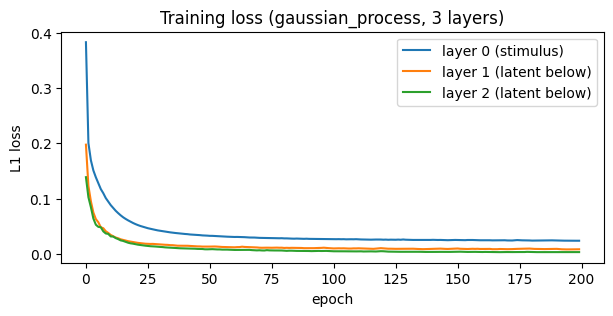

In [18]:
fig, ax = plt.subplots(figsize=(7, 3))
for i in range(NUM_LAYERS):
    label = 'layer 0 (stimulus)' if i == 0 else f'layer {i} (latent below)'
    ax.plot(losses[i], label=label)
ax.set_xlabel('epoch')
ax.set_ylabel('L1 loss')
ax.set_title(f'Training loss ({TASK}, {NUM_LAYERS} layers)')
ax.legend()
plt.show()

## Evaluate and visualize

The model is put in `eval()` mode, so the latent noise is disabled. Predictions
are aligned so `prediction[t]` sits against its target `input[t+1]`.


In [19]:
model.eval()
with torch.no_grad():
    out = model(eval_x)

# Per-layer numpy views (drop the batch dim; NUM_EVAL_SEQ = 1).
inputs = [out['inputs'][i][0].numpy() for i in range(NUM_LAYERS)]       # what layer i predicts
preds  = [out['predictions'][i][0].numpy() for i in range(NUM_LAYERS)]  # layer i's prediction
hidden = [out['hidden'][i][0].numpy() for i in range(NUM_LAYERS)]       # layer i's latents

# Per-layer next-step L1 (pred[:-1] vs input[1:]).
layer_l1 = [float(np.abs(preds[i][:-1] - inputs[i][1:]).mean()) for i in range(NUM_LAYERS)]
for i, v in enumerate(layer_l1):
    what = 'stimulus' if i == 0 else f'layer-{i-1} latent'
    print(f'layer {i} eval mean L1 ({what}): {v:.4f}')

layer 0 eval mean L1 (stimulus): 0.0237
layer 1 eval mean L1 (layer-0 latent): 0.0055
layer 2 eval mean L1 (layer-1 latent): 0.0017


### Layer 0: predictions vs. ground-truth stimulus

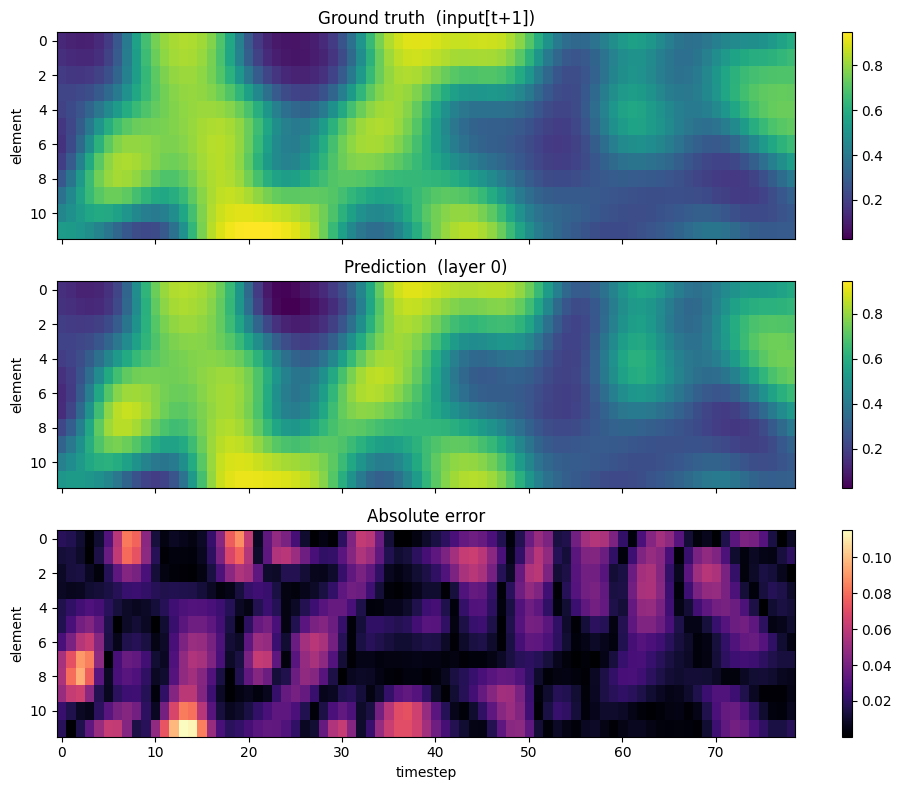

In [20]:
seq = inputs[0]           # (T, D) stimulus
pred0 = preds[0]          # (T, D) pred0[t] predicts stimulus[t+1]
target = seq[1:]
pred_aligned = pred0[:-1]

vmin = min(target.min(), pred_aligned.min())
vmax = max(target.max(), pred_aligned.max())

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
im0 = axes[0].imshow(target.T, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax,
                     interpolation='nearest')
axes[0].set_ylabel('element'); axes[0].set_title('Ground truth  (input[t+1])')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(pred_aligned.T, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax,
                     interpolation='nearest')
axes[1].set_ylabel('element'); axes[1].set_title('Prediction  (layer 0)')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(np.abs(pred_aligned - target).T, aspect='auto', cmap='magma',
                     interpolation='nearest')
axes[2].set_ylabel('element'); axes[2].set_xlabel('timestep')
axes[2].set_title('Absolute error')
fig.colorbar(im2, ax=axes[2])
plt.tight_layout()
plt.show()

### Layer 0: a few elements, prediction overlaid on ground truth

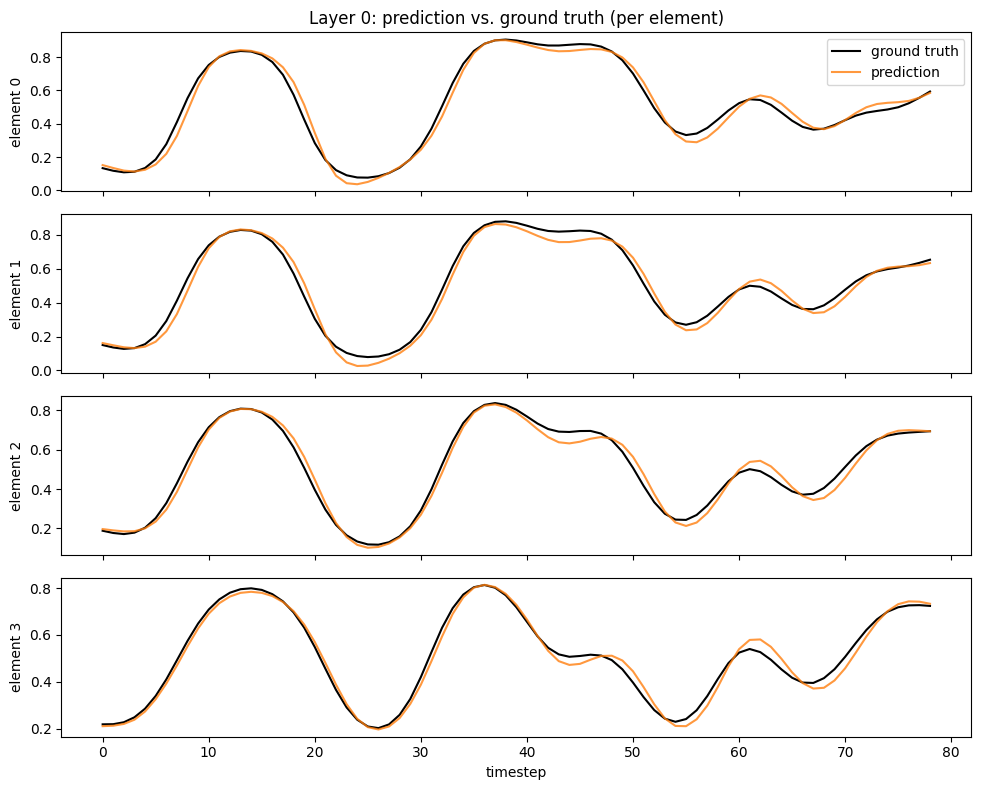

In [21]:
elements = list(range(min(4, VECTOR_LENGTH)))
fig, axes = plt.subplots(len(elements), 1, figsize=(10, 2 * len(elements)), sharex=True)
if len(elements) == 1:
    axes = [axes]
for ax, e in zip(axes, elements):
    ax.plot(target[:, e], label='ground truth', color='k', lw=1.5)
    ax.plot(pred_aligned[:, e], label='prediction', color='C1', lw=1.5, alpha=0.8)
    ax.set_ylabel(f'element {e}')
axes[0].legend(loc='upper right')
axes[-1].set_xlabel('timestep')
axes[0].set_title('Layer 0: prediction vs. ground truth (per element)')
plt.tight_layout()
plt.show()

### Latent-space activity for every layer

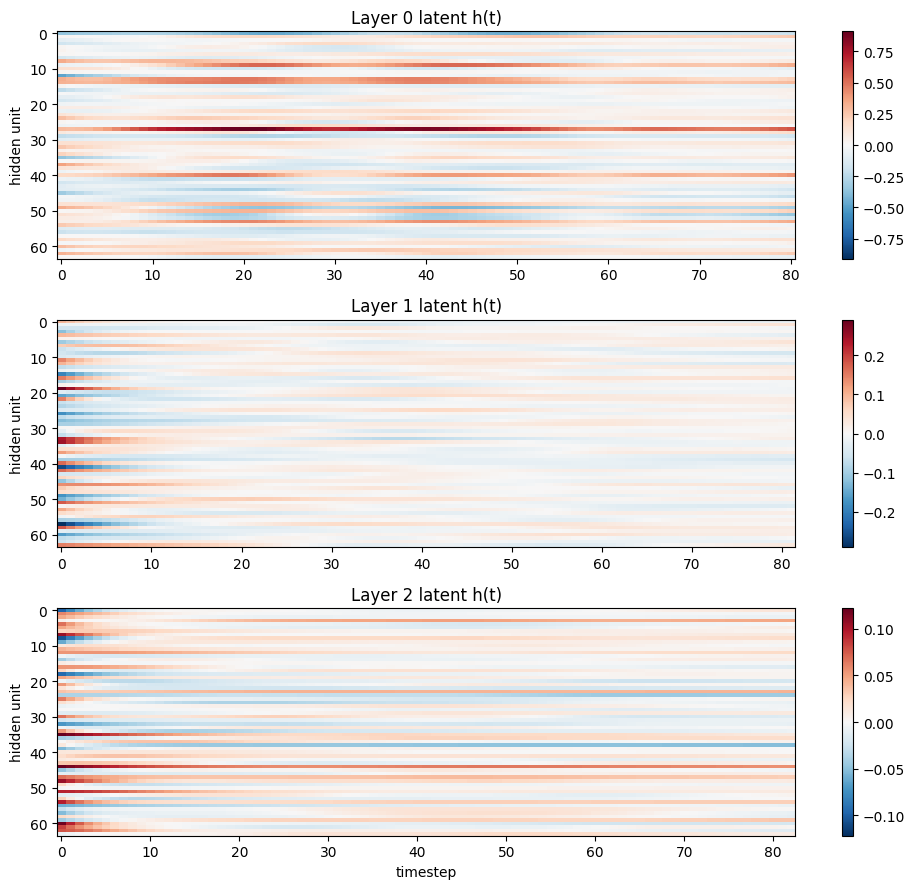

In [22]:
fig, axes = plt.subplots(NUM_LAYERS, 1, figsize=(10, 3 * NUM_LAYERS), squeeze=False)
for i in range(NUM_LAYERS):
    ax = axes[i][0]
    latent = hidden[i]
    scale = np.abs(latent).max()
    im = ax.imshow(latent.T, aspect='auto', cmap='RdBu_r', vmin=-scale, vmax=scale,
                   interpolation='nearest')
    ax.set_ylabel('hidden unit')
    ax.set_title(f'Layer {i} latent h(t)')
    fig.colorbar(im, ax=ax)
axes[-1][0].set_xlabel('timestep')
plt.tight_layout()
plt.show()

### Per-layer next-step L1 error

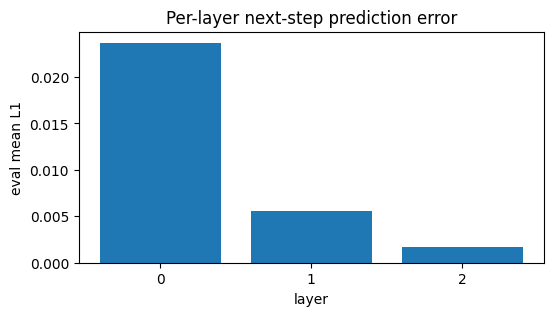

In [23]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(NUM_LAYERS), layer_l1, color='C0')
ax.set_xticks(range(NUM_LAYERS))
ax.set_xlabel('layer')
ax.set_ylabel('eval mean L1')
ax.set_title('Per-layer next-step prediction error')
plt.show()

### Higher layers: predicting the latent trajectory below

For each layer above the input, the (detached) latent trajectory it consumes,
its prediction of the next latent, and the error.


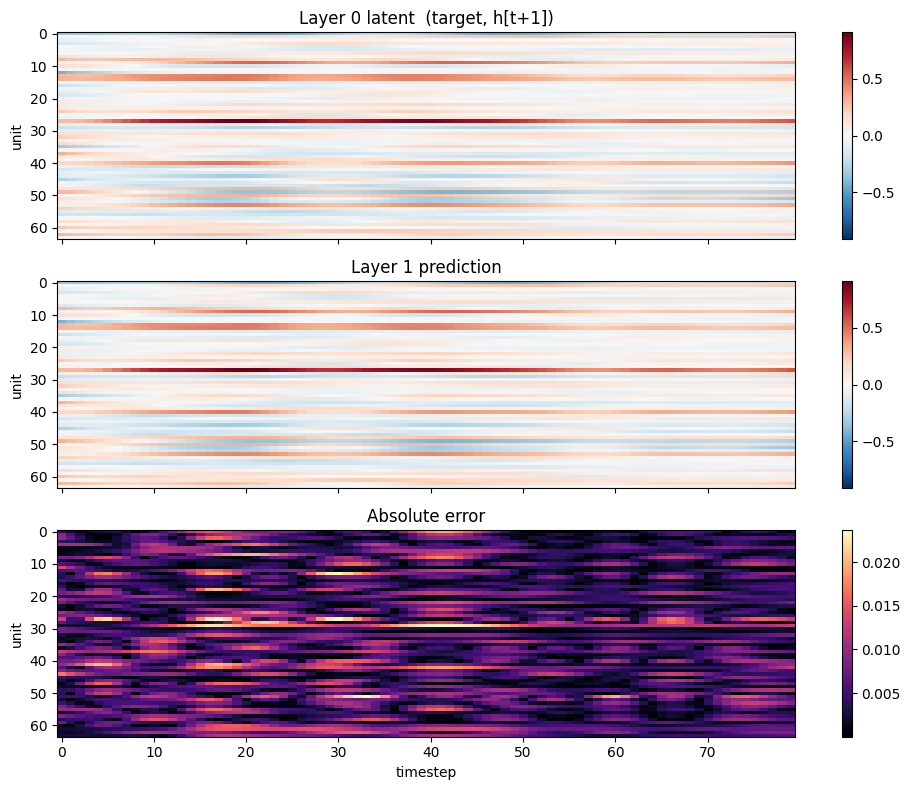

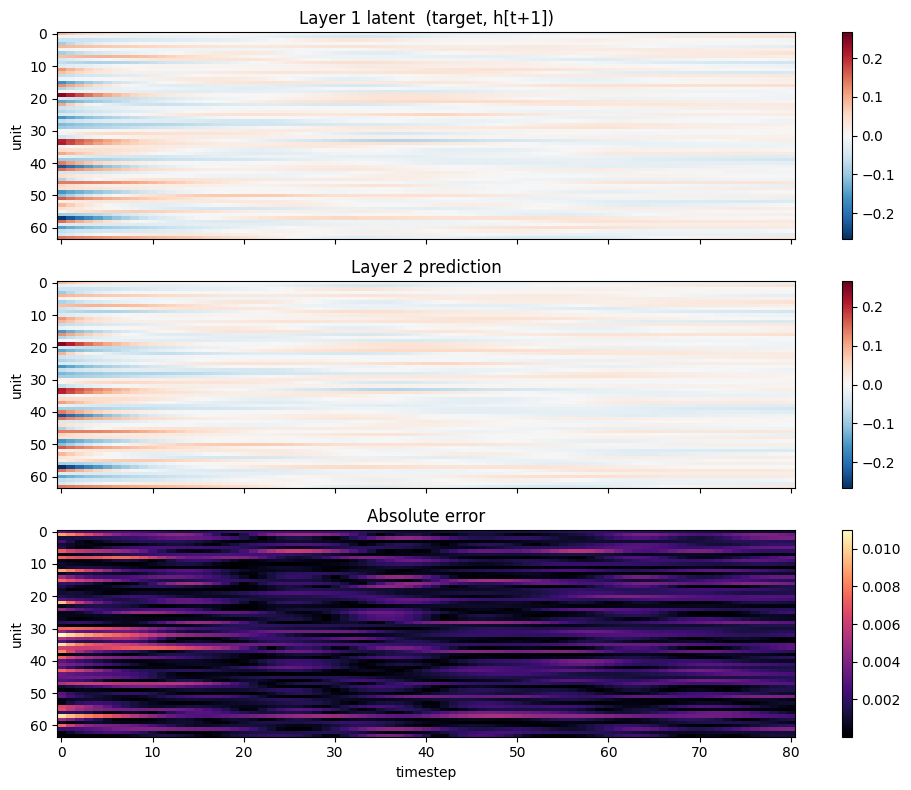

In [24]:
for i in range(1, NUM_LAYERS):
    tgt = inputs[i][1:]      # layer-(i-1) latents at t+1
    prd = preds[i][:-1]      # layer i's prediction of them
    scale = np.abs(np.concatenate([tgt, prd])).max()

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    im0 = axes[0].imshow(tgt.T, aspect='auto', cmap='RdBu_r', vmin=-scale, vmax=scale,
                         interpolation='nearest')
    axes[0].set_ylabel('unit'); axes[0].set_title(f'Layer {i-1} latent  (target, h[t+1])')
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(prd.T, aspect='auto', cmap='RdBu_r', vmin=-scale, vmax=scale,
                         interpolation='nearest')
    axes[1].set_ylabel('unit'); axes[1].set_title(f'Layer {i} prediction')
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(np.abs(prd - tgt).T, aspect='auto', cmap='magma',
                         interpolation='nearest')
    axes[2].set_ylabel('unit'); axes[2].set_xlabel('timestep')
    axes[2].set_title('Absolute error')
    fig.colorbar(im2, ax=axes[2])
    plt.tight_layout()
    plt.show()